# B19013_001E Time Series (2012-2024) for Selected CA ZCTAs

This notebook plots median household income (`B19013_001E`) from yearly ACS files for selected ZIP/ZCTA codes.


In [10]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

ZIP_COL = "ZCTA5"
VALUE_COL = "B19013_001E"
FILE_PATTERN = "acs_*_demographics_ca_zcta.csv"
YEAR_RE = re.compile(r"acs_(\d{4})_demographics_ca_zcta\.csv$")
START_YEAR = 2012
END_YEAR = 2024

TARGET_ZIPS = [
    "92602", "92603", "92604", "92606", "92612",
    "92614", "92617", "92618", "92620", #"92697",
]


def load_income_series(data_dir: Path, target_zips: list[str]) -> pd.DataFrame:
    records = []
    target_set = set(target_zips)

    for path in sorted(data_dir.glob(FILE_PATTERN)):
        m = YEAR_RE.match(path.name)
        if not m:
            continue
        year = int(m.group(1))
        if year < START_YEAR or year > END_YEAR:
            continue

        df = pd.read_csv(path, usecols=[ZIP_COL, VALUE_COL], dtype=str)
        df[ZIP_COL] = df[ZIP_COL].astype(str).str.strip().str.zfill(5)
        df = df[df[ZIP_COL].isin(target_set)].copy()
        if df.empty:
            continue

        df[VALUE_COL] = pd.to_numeric(
            df[VALUE_COL].astype(str).str.replace(",", "", regex=False),
            errors="coerce",
        )
        # ACS sentinel negatives (e.g., -666666666) mean unavailable values.
        df.loc[df[VALUE_COL] < 0, VALUE_COL] = pd.NA

        df = df.drop_duplicates(subset=[ZIP_COL], keep="first")
        df["year"] = year
        records.append(df[[ZIP_COL, "year", VALUE_COL]])

    if not records:
        raise RuntimeError("No matching records found in the requested year range.")

    out = pd.concat(records, ignore_index=True)
    return out.sort_values(["year", ZIP_COL]).reset_index(drop=True)


def plot_income_series(df: pd.DataFrame, target_zips: list[str], out_path: Path) -> None:
    pivot = df.pivot(index="year", columns=ZIP_COL, values=VALUE_COL)
    pivot = pivot.reindex(columns=target_zips).sort_index()

    ax = pivot.plot(figsize=(12, 7), marker="o", linewidth=2)
    # set y axis start at 0
    ax.set_ylim(bottom=0)
    ax.set_title("Median Household Income Estimate from 2012-2024 for Irvine ZCTAs")
    ax.set_xlabel("Year")
    ax.set_ylabel("Income (2024 inflation-adjusted dollars)")
    ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.4)
    ax.legend(title="ZCTA5", ncol=2, frameon=False)

    plt.tight_layout()
    plt.savefig(out_path, dpi=220)
    plt.show()


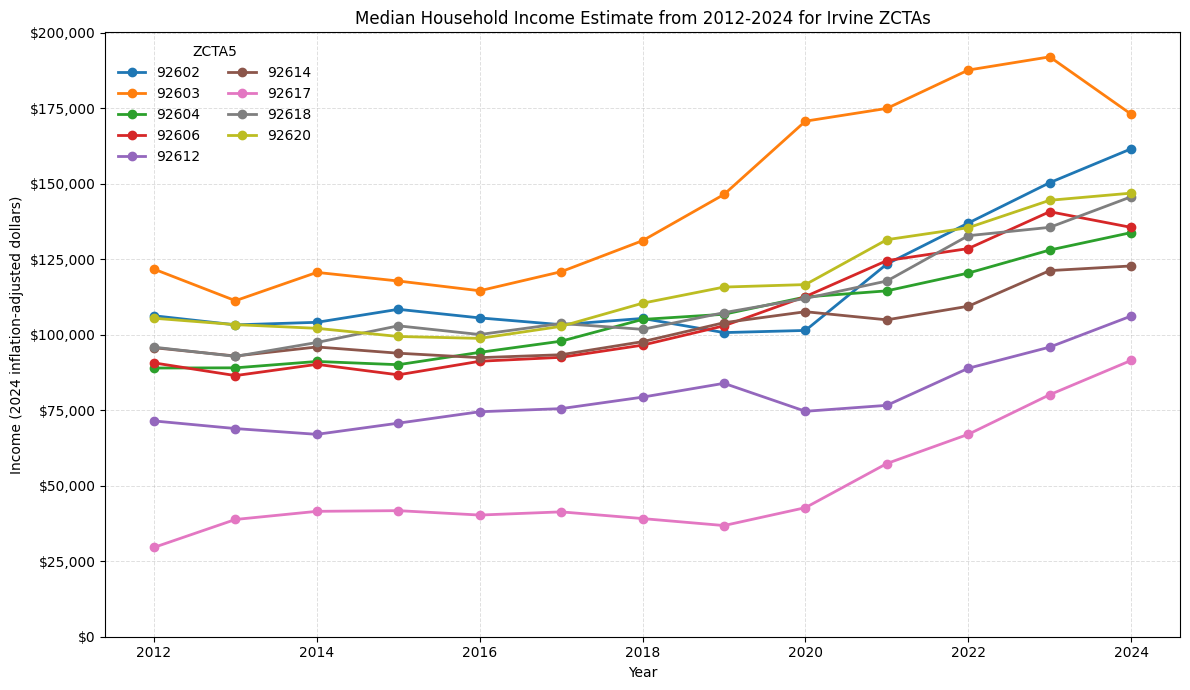

Years loaded: 2012-2024 (13 years)
ZCTAs: 92602, 92603, 92604, 92606, 92612, 92614, 92617, 92618, 92620
Saved figure: b19013_selected_zctas_timeseries.png


In [11]:
PROJECT_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'data' / 'zcta_archive' / 'raw').exists())
data_dir = PROJECT_ROOT / 'data' / 'zcta_archive' / 'raw'
output_path = PROJECT_ROOT / 'outputs' / 'zcta-exploration' / 'b19013_selected_zctas_timeseries.png'
output_path.parent.mkdir(parents=True, exist_ok=True)

df_income = load_income_series(data_dir, TARGET_ZIPS)
plot_income_series(df_income, TARGET_ZIPS, output_path)

years_loaded = sorted(df_income['year'].unique().tolist())
print(f"Years loaded: {years_loaded[0]}-{years_loaded[-1]} ({len(years_loaded)} years)")
print(f"ZCTAs: {', '.join(TARGET_ZIPS)}")
print(f"Saved figure: {output_path}")


In [5]:
# Optional: inspect the underlying long-format data

df_income.head(20)


,ZCTA5,year,B19013_001E
0,92602,2012,106322.0
1,92603,2012,121769.0
2,92604,2012,89009.0
3,92606,2012,90707.0
4,92612,2012,71480.0
5,92614,2012,95733.0
6,92617,2012,29590.0
7,92618,2012,95917.0
8,92620,2012,105501.0
9,92602,2013,103309.0
